<a href="https://colab.research.google.com/github/jaysonDfernandez/Machine-Learning-Models/blob/main/Transformer_Based_MNQ_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch pandas numpy scikit-learn
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=8d8eb18b0cfad0574cc0e8714780ddc21342384a8bf1db3f750c4f7393d518ef
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


Using device: cpu


/tmp/ipython-input-265658365.py:112: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([256, 1])) that is different to the input size (torch.Size([256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([250, 1])) that is different to the input s

Epoch 1: train=0.397980, val=4.574096
Epoch 2: train=0.365029, val=4.575419
Epoch 3: train=0.359329, val=4.572666
Epoch 4: train=0.355862, val=4.572572
Epoch 5: train=0.355903, val=4.572773
Epoch 6: train=0.354294, val=4.572217
Epoch 7: train=0.354242, val=4.571317
Epoch 8: train=0.355398, val=4.572216
Epoch 9: train=0.353355, val=4.571632
Epoch 10: train=0.352974, val=4.571150
Epoch 11: train=0.353379, val=4.571253
Epoch 12: train=0.352894, val=4.570792
Epoch 13: train=0.352803, val=4.570478
Epoch 14: train=0.353715, val=4.570798
Epoch 15: train=0.352666, val=4.570587
Epoch 16: train=0.352872, val=4.570423
Epoch 17: train=0.352753, val=4.570777
Epoch 18: train=0.353276, val=4.570673
Epoch 19: train=0.352327, val=4.570501
Epoch 20: train=0.352827, val=4.570567
Epoch 21: train=0.352618, val=4.571160
Epoch 22: train=0.353137, val=4.570534
Epoch 23: train=0.353018, val=4.570810
Epoch 24: train=0.353542, val=4.570721
Epoch 25: train=0.352761, val=4.571043
Epoch 26: train=0.352917, val=4.57

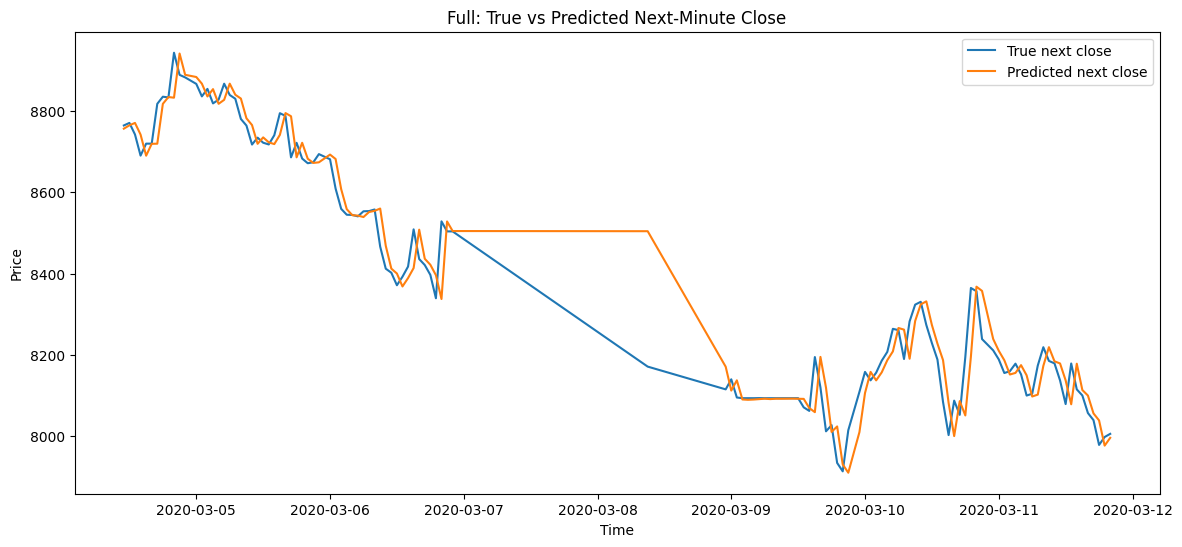

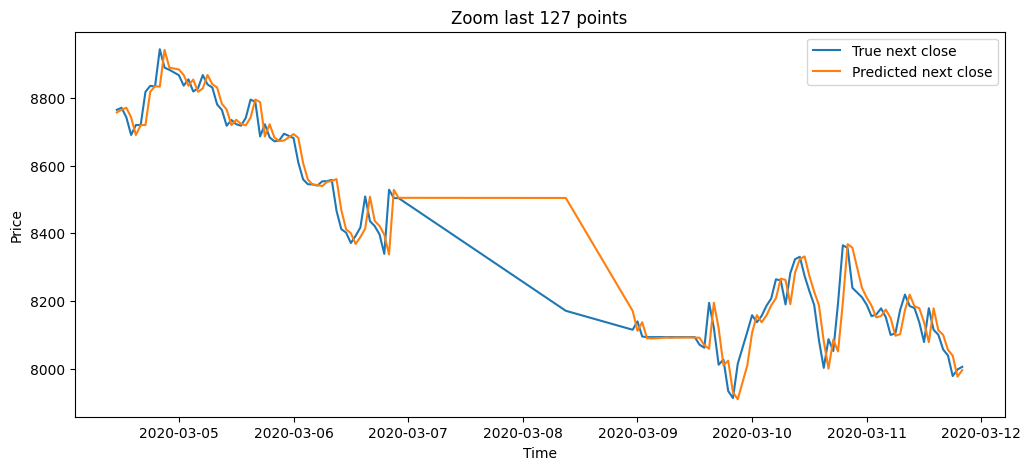

In [ ]:
# ------------------------------------------------------------
#  Transformer model for MNQ minute-level forecasting
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os
from sklearn.preprocessing import MinMaxScaler
import ta
import io


# ============================================================
# 1. Dataset and sequence helpers
# ============================================================
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(data, target_index, seq_length=240, pred_length=1):
    X, y = [], []
    for i in range(len(data) - seq_length - pred_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+pred_length, target_index])
    return np.array(X), np.array(y)

# ============================================================
# 2.  Transformer model
# ============================================================

class ImprovedTimeSeriesTransformer(nn.Module):
    def __init__(self, feature_size, seq_length, prediction_length, num_layers=2, nhead=4, dropout=0.1):
        super().__init__()
        self.feature_size = feature_size
        self.seq_length = seq_length
        self.prediction_length = prediction_length

        self.input_proj = nn.Linear(feature_size, 128)
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=nhead,
                                                   dim_feedforward=256, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, prediction_length)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = x.permute(1, 0, 2)
        x = self.transformer(x)
        x = x[-1]
        return self.fc(x)


# ============================================================
# 3. Data loading and feature engineering for minute data
# ============================================================
def load_csv_minute(filepath):
    df = pd.read_csv(filepath)
    datetime_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
    dt_col = datetime_cols[0] if datetime_cols else df.columns[0]
    df.rename(columns={dt_col: 'datetime'}, inplace=True)
    df['datetime'] = pd.to_datetime(df['datetime'], format='%d.%m.%Y %H:%M:%S.%f', errors='coerce', dayfirst=True)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce', dayfirst=True)
    df.dropna(subset=['datetime'], inplace=True)
    df.set_index('datetime', inplace=True)
    df.rename(columns=lambda x: x.strip().lower(), inplace=True)
    return df

def add_minute_features(df, resample_minutes=None):
    df = df.copy()
    if resample_minutes is not None and resample_minutes > 1:
        rule = f'{resample_minutes}T'
        agg = {'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'}
        try:
            df = df.resample(rule).agg(agg).dropna()
        except:
            df = df.resample(rule).last().dropna()

    df['sma_5'] = df['close'].rolling(5, min_periods=1).mean()
    df['sma_20'] = df['close'].rolling(20, min_periods=1).mean()
    df['ema_10'] = df['close'].ewm(span=10, adjust=False).mean()
    df['mom_5'] = df['close'] - df['close'].shift(5)
    df['range'] = df['high'] - df['low']
    df['atr_14'] = df['range'].rolling(14, min_periods=1).mean()
    df['sma5_div_close'] = df['sma_5'] / (df['close'] + 1e-8)
    df['ema10_div_close'] = df['ema_10'] / (df['close'] + 1e-8)

    df['return_1'] = df['close'].pct_change().shift(-1)

    minute_of_day = df.index.hour * 60 + df.index.minute
    df['sin_minute'] = np.sin(2 * np.pi * minute_of_day / (24 * 60))
    df['cos_minute'] = np.cos(2 * np.pi * minute_of_day / (24 * 60))
    hour = df.index.hour
    df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
    df['cos_hour'] = np.cos(2 * np.pi * hour / 24)
    dow = df.index.dayofweek
    df['sin_dow'] = np.sin(2 * np.pi * dow / 7)
    df['cos_dow'] = np.cos(2 * np.pi * dow / 7)

    df.fillna(method='ffill', inplace=True)
    df.dropna(inplace=True)
    return df

def select_and_scale_features_minute(df, target_col='return_1', scaler=None):
    cand = [
        'open', 'high', 'low', 'close', 'volume',
        'sma_5', 'sma_20', 'ema_10', 'mom_5', 'atr_14',
        'sma5_div_close', 'ema10_div_close',
        'sin_minute', 'cos_minute', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow',
        target_col
    ]
    feature_cols = [c for c in cand if c in df.columns]
    data = df[feature_cols].astype(float).values
    scaler = StandardScaler() if scaler is None else scaler
    data_scaled = scaler.fit_transform(data)
    target_index = feature_cols.index(target_col)
    return data_scaled, scaler, feature_cols, target_index

# ============================================================
# 4. Training utilities
# ============================================================
def train_model(model, train_loader, val_loader=None, lr=5e-4, epochs=60, device='cpu', early_stop_patience=10):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val = float('inf')
    patience = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(Xb).squeeze()
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)

        val_loss = None
        if val_loader:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for Xv, yv in val_loader:
                    Xv, yv = Xv.to(device), yv.to(device)
                    pv = model(Xv).squeeze()
                    val_loss += criterion(pv, yv).item()
            val_loss /= len(val_loader)
            print(f"Epoch {epoch+1}: train={avg_train_loss:.6f}, val={val_loss:.6f}")
            if val_loss < best_val:
                best_val = val_loss
                patience = 0
                best_state = model.state_dict()
            else:
                patience += 1
                if patience >= early_stop_patience:
                    print(f"Early stopping after {epoch+1} epochs. Best val: {best_val:.6f}")
                    model.load_state_dict(best_state)
                    break
    return model

def evaluate_model(model, loader, device='cpu'):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb).squeeze().cpu().numpy()
            preds.append(pred)
            trues.append(yb.cpu().numpy())
    return np.concatenate(preds), np.concatenate(trues)



# ============================================================
# 5. Pipeline runner
# ============================================================
def run_minute_pipeline(csv_path,
                        seq_length=240,
                        pred_length=1,
                        resample_minutes=None,
                        test_size=0.1,
                        val_size=0.1,
                        batch_size=256,
                        device=None,
                        epochs=60):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print('Using device:', device)

    df = load_csv_minute(csv_path)
    df = add_minute_features(df, resample_minutes=resample_minutes)
    scaled_data, scaler, feature_cols, target_index = select_and_scale_features_minute(df)
    X, y = create_sequences(scaled_data, target_index, seq_length, pred_length)

    n = len(X)
    test_n = max(1, int(n * test_size))
    val_n = max(1, int(n * val_size))
    train_n = n - val_n - test_n
    X_train, y_train = X[:train_n], y[:train_n]
    X_val, y_val = X[train_n:train_n + val_n], y[train_n:train_n + val_n]
    X_test, y_test = X[train_n + val_n:], y[train_n + val_n:]

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=batch_size)
    test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=batch_size)

    model = ImprovedTimeSeriesTransformer(feature_size=len(feature_cols), seq_length=seq_length, prediction_length=pred_length)
    model = train_model(model, train_loader, val_loader, epochs=epochs, device=device, early_stop_patience=12)

    preds_scaled, trues_scaled = evaluate_model(model, test_loader, device)
    def inv_scale_return(arr):
        arr = arr.reshape(-1)
        dummy = np.zeros((len(arr), len(feature_cols)))
        dummy[:, target_index] = arr
        return scaler.inverse_transform(dummy)[:, target_index]




    preds_ret = inv_scale_return(preds_scaled)
    trues_ret = inv_scale_return(trues_scaled)

    df_index = df.index[seq_length:]
    test_dates = df_index[train_n + val_n:train_n + val_n + len(preds_ret)]
    close_vals = df['close'].values[seq_length:][train_n + val_n:train_n + val_n + len(preds_ret)]

    pred_prices = close_vals * (1 + preds_ret)
    true_prices = close_vals * (1 + trues_ret)

    out_df = pd.DataFrame({
        'timestamp': test_dates,
        'close_t': close_vals,
        'true_next_close': true_prices,
        'pred_next_close': pred_prices,
        'true_return': trues_ret,
        'pred_return': preds_ret
    })
    out_df.to_csv('mnq_minute_predictions.csv', index=False)

    plt.figure(figsize=(14, 6))
    plt.plot(out_df['timestamp'], out_df['true_next_close'], label='True next close')
    plt.plot(out_df['timestamp'], out_df['pred_next_close'], label='Predicted next close')
    plt.legend(); plt.title('Full: True vs Predicted Next-Minute Close'); plt.xlabel('Time'); plt.ylabel('Price')
    plt.savefig('mnq_minute_full.png', bbox_inches='tight')

    zoom_n = min(200, len(out_df))
    plt.figure(figsize=(12, 5))
    plt.plot(out_df['timestamp'].iloc[-zoom_n:], out_df['true_next_close'].iloc[-zoom_n:], label='True next close')
    plt.plot(out_df['timestamp'].iloc[-zoom_n:], out_df['pred_next_close'].iloc[-zoom_n:], label='Predicted next close')
    plt.legend(); plt.title(f'Zoom last {zoom_n} points'); plt.xlabel('Time'); plt.ylabel('Price')
    plt.savefig('mnq_minute_zoom.png', bbox_inches='tight')


    mse = np.mean((pred_prices - true_prices) ** 2)
    mae = np.mean(np.abs(pred_prices - true_prices))
    print(f'Test Price MSE: {mse:.6f}, MAE: {mae:.6f}')

    # -------------------------------------------------------
    # SAVE TRAINED MODEL CHECKPOINT (.pth)
    # -------------------------------------------------------
    SAVE_PATH = "/content/drive/MyDrive/MachineLearning/trained_transformer_model.pth"

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "scaler": scaler,
        "feature_cols": feature_cols,
        "seq_length": seq_length,
        "pred_length": pred_length,
        "target_index": target_index
    }

    torch.save(checkpoint, SAVE_PATH)
    print(f"\nModel saved successfully → {SAVE_PATH}\n")

    return out_df


# ============================================================
# 6. Main entry
# ============================================================
if __name__ == '__main__':
    CSV_PATH = '/content/drive/MyDrive/MachineLearning/MNQ Data/MNQdata.csv'
    results = run_minute_pipeline(CSV_PATH,
                                  seq_length=240,
                                  pred_length=1,
                                  resample_minutes=None,  # or 5 or 15 to smooth
                                  batch_size=256,
                                  epochs=60)


In [ ]:
print("model:", 'OK' if 'model' in globals() else 'MISSING')
print("scaler:", 'OK' if 'scaler' in globals() else 'MISSING')
print("feature_cols:", 'OK' if 'feature_cols' in globals() else 'MISSING')
print("seq_length:", 'OK' if 'seq_length' in globals() else 'MISSING')
print("prediction_length:", 'OK' if 'prediction_length' in globals() else 'MISSING')
print("target_index:", 'OK' if 'target_index' in globals() else 'MISSING')


model: OK
scaler: OK
feature_cols: OK
seq_length: OK
prediction_length: MISSING
target_index: OK


In [ ]:
import os
os.path.exists("/content/drive/MyDrive/MachineLearning/trained_transformer_model.pth")


True

In [ ]:
import torch
from sklearn.preprocessing import StandardScaler

torch.serialization.add_safe_globals([StandardScaler])


In [ ]:
LOAD_PATH = "/content/drive/MyDrive/MachineLearning/trained_transformer_model.pth"
checkpoint = torch.load(LOAD_PATH, map_location="cpu", weights_only=False)

print("Checkpoint loaded OK.")


Checkpoint loaded OK.


In [ ]:
import torch
from sklearn.preprocessing import StandardScaler

# Allow unpickling of StandardScaler
torch.serialization.add_safe_globals([StandardScaler])

LOAD_PATH = "/content/drive/MyDrive/MachineLearning/trained_transformer_model.pth"

checkpoint = torch.load(LOAD_PATH, map_location="cpu", weights_only=False)

model_state = checkpoint["model_state_dict"]
scaler = checkpoint["scaler"]
feature_cols = checkpoint["feature_cols"]
seq_length = checkpoint["seq_length"]
pred_length = checkpoint["pred_length"]
target_index = checkpoint["target_index"]

print("Loaded checkpoint keys:", list(checkpoint.keys()))


Loaded checkpoint keys: ['model_state_dict', 'scaler', 'feature_cols', 'seq_length', 'pred_length', 'target_index']


In [ ]:
import torch
import torch.nn as nn

class ImprovedTimeSeriesTransformer(nn.Module):
    def __init__(self, feature_size, seq_length, prediction_length, num_layers=2, nhead=4, dropout=0.1):
        super().__init__()
        self.feature_size = feature_size
        self.seq_length = seq_length
        self.prediction_length = prediction_length

        self.input_proj = nn.Linear(feature_size, 128)
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=nhead,
                                                   dim_feedforward=256, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, prediction_length)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = x.permute(1, 0, 2)
        x = self.transformer(x)
        x = x[-1]
        return self.fc(x)


In [ ]:
LOAD_PATH = "/content/drive/MyDrive/MachineLearning/trained_transformer_model.pth"

checkpoint = torch.load(
    LOAD_PATH,
    map_location="cpu",
    weights_only=False  # required because checkpoint includes StandardScaler
)

model_state = checkpoint["model_state_dict"]
scaler = checkpoint["scaler"]
feature_cols = checkpoint["feature_cols"]
seq_length = checkpoint["seq_length"]
pred_length = checkpoint["pred_length"]
target_index = checkpoint["target_index"]

print("Checkpoint loaded!")


Checkpoint loaded!


In [ ]:
model = ImprovedTimeSeriesTransformer(
    feature_size=len(feature_cols),
    seq_length=seq_length,
    prediction_length=pred_length
)

model.load_state_dict(model_state)
model.eval()

print("Model restored successfully!")


Model restored successfully!


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
!pip install flash


In [ ]:
!pip install flask pyngrok


In [ ]:
!pip install flask flask-ngrok pyngrok


In [ ]:
!pip install flask pyngrok --quiet


In [ ]:
from pyngrok import ngrok

# Set
ngrok.set_auth_token("35Rde5Rp9IVQyOoREYJ0OHkWDGq_61mnNkn2WpDkn333KDiNN")

# Start ngrok on port 5000 (default Flask port)
public_url = ngrok.connect(5000)
print("Ngrok tunnel URL:", public_url)

Ngrok tunnel URL: NgrokTunnel: "https://omental-deflectingly-valrie.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
from flask import Flask, request, jsonify
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    return jsonify({"message": "Hello, this is working!"})

if __name__ == "__main__":
    app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [14/Nov/2025 00:04:56] "GET / HTTP/1.1" 404 -


In [ ]:
ngrok.kill()